### 인사이트 도출을 위한 시각화

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [5]:
print(df_A_valid.columns.tolist())


['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'elapsed_hours_from_first', 'hours_from_prev_operation', 'group', 'end_reason', 'analysis_role', 'test_temperature_profile', 'load_profile', 'eol_rule_source', 'cutoff_voltage', 'discharge_current', 'eol_fade_threshold', 'cap_flag', 'cap_exclude', 'cap_anomaly', 'discharge_cycle_raw', 'is_hard_excluded', 'discharge_cycle_valid', 'init_cap', 'SOH_nominal', 'SOH_relative', 'eol_soh_threshold', 'eol_cycle', 'RUL', 'rul_label_type']


In [2]:
base_path = 'data/new_data'
 
# 전처리 결과 로드
df_A       = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_C       = pd.read_csv(os.path.join(base_path, 'df_C_comparison.csv'))
df_anomaly = pd.read_csv(os.path.join(base_path, 'df_anomaly.csv'))
df_imp_A   = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
df_imp_C   = pd.read_csv(os.path.join(base_path, 'df_imp_C_comparison.csv'))
 
# valid 행만 사용
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
df_C_valid = df_C[df_C['cap_flag'] == 'valid'].copy()
 
# impedance 순번 추가
df_imp_A = df_imp_A.sort_values(['battery_id','test_id'])
df_imp_A['imp_cycle_no'] = df_imp_A.groupby('battery_id').cumcount() + 1
df_imp_C = df_imp_C.sort_values(['battery_id','test_id'])
df_imp_C['imp_cycle_no'] = df_imp_C.groupby('battery_id').cumcount() + 1
 
# 배터리별 EOL 사이클 추출
def get_eol(df, threshold=70):
    eol = (
        df[df['SOH_nominal'] < threshold]
        .groupby('battery_id')['discharge_cycle_raw']
        .min()
        .reset_index()
        .rename(columns={'discharge_cycle_raw': 'eol_cycle'})
    )
    eol['group'] = eol['battery_id'].map(
        df.set_index('battery_id')['group'].to_dict()
    )
    eol['temperature'] = eol['battery_id'].map(
        df.groupby('battery_id')['ambient_temperature'].first().to_dict()
    )
    return eol

eol_A = get_eol(df_A_valid)
eol_C = get_eol(df_C_valid)
eol_all = pd.concat([eol_A, eol_C], ignore_index=True)
 
print("=" * 55)
print("데이터 로드 완료")
print("=" * 55)
print(f"df_A_valid   : {len(df_A_valid)}행  {df_A_valid['battery_id'].nunique()}개 배터리")
print(f"df_C_valid   : {len(df_C_valid)}행  {df_C_valid['battery_id'].nunique()}개 배터리")
print(f"df_imp_A     : {len(df_imp_A)}행")
print(f"df_imp_C     : {len(df_imp_C)}행")
print(f"\n배터리별 EOL 사이클:")
print(eol_all.to_string(index=False))

데이터 로드 완료
df_A_valid   : 636행  4개 배터리
df_C_valid   : 160행  4개 배터리
df_imp_A     : 887행
df_imp_C     : 68행

배터리별 EOL 사이클:
battery_id  eol_cycle group  temperature
     B0005        125     A           24
     B0006        109     A           24
     B0018         97     A           24


# EDA

# 1. SOH 분포 박스플롯

- 왼쪽 차트: 배터리 8개(A·C 그룹) 각각의 SOH 분포
- 오른쪽 차트: 그룹A(상온) vs 그룹C(고온) 전체 분포 비교


- 빨간 점선(SOH 80%)이 EOL 기준선. 이 선 아래로 많이 내려간 배터리일수록 노화가 심함.

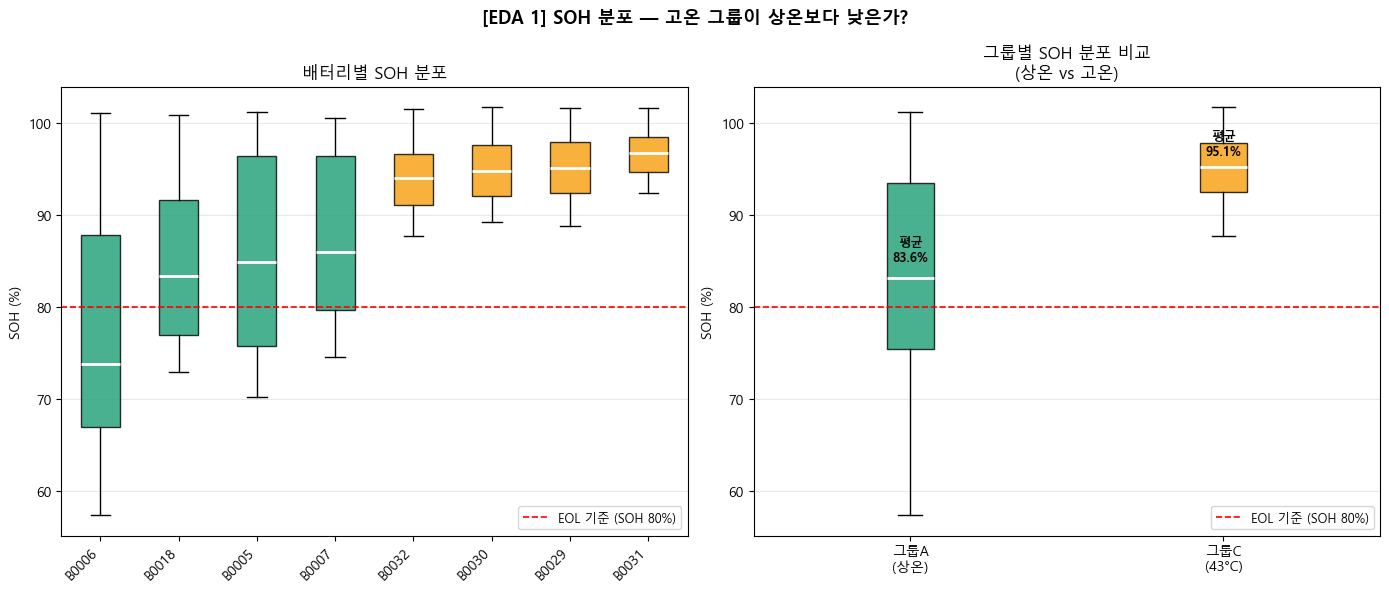

[저장] eda1_soh_distribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# 왼쪽: 배터리별 SOH 박스플롯
combined = pd.concat([df_A_valid, df_C_valid])
battery_order = (
    combined.groupby('battery_id')['SOH']
    .median()
    .sort_values()
    .index.tolist()
)
colors_box = [
    GROUP_COLORS.get(combined[combined['battery_id']==b]['group'].iloc[0], 'gray')
    for b in battery_order
]
bp = axes[0].boxplot(
    [combined[combined['battery_id']==b]['SOH'].dropna().values
     for b in battery_order],
    labels=battery_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
 
axes[0].axhline(y=80, color='red', linestyle='--', linewidth=1.2,
                label='EOL 기준 (SOH 80%)')
axes[0].set_title('배터리별 SOH 분포')
axes[0].set_ylabel('SOH (%)')
axes[0].set_xticklabels(battery_order, rotation=45, ha='right')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
 
# 오른쪽: 그룹별 SOH 박스플롯
group_data = {
    '그룹A\n(상온)': df_A_valid['SOH'].dropna().values,
    '그룹C\n(43°C)': df_C_valid['SOH'].dropna().values,
}
bp2 = axes[1].boxplot(
    list(group_data.values()),
    labels=list(group_data.keys()),
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
group_colors_list = [GROUP_COLORS['A'], GROUP_COLORS['C']]
for patch, color in zip(bp2['boxes'], group_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
 
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.2,
                label='EOL 기준 (SOH 80%)')
axes[1].set_title('그룹별 SOH 분포 비교\n(상온 vs 고온)')
axes[1].set_ylabel('SOH (%)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
 
# 그룹별 평균 SOH 표시
for i, (label, data) in enumerate(group_data.items()):
    axes[1].text(i+1, np.mean(data)+1, f'평균\n{np.mean(data):.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
 
fig.suptitle('[EDA 1] SOH 분포 — 고온 그룹이 상온보다 낮은가?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda1_soh_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda1_soh_distribution.png')


# 2. 배터리별 열화 곡선 (Capacity vs 사이클)

- x축: 방전 사이클 번호 (충전·방전을 반복한 횟수)
- y축: Capacity (배터리가 저장할 수 있는 전기량, Ah)
- 실선: 원본 데이터
- 점선: rolling median (잡음 제거 추세선)

한 번 뚝 떨어졌다가 회복하는 패턴 = 고장이 아님. 리튬이온 배터리에서 알려진 일시적 회복 현상이라 "일시적 이상값"으로 표현.

- 왼쪽: 그룹A 배터리 4개 개별 비교
- 오른쪽: 그룹A(초록) vs 그룹C(주황) 온도별 비교

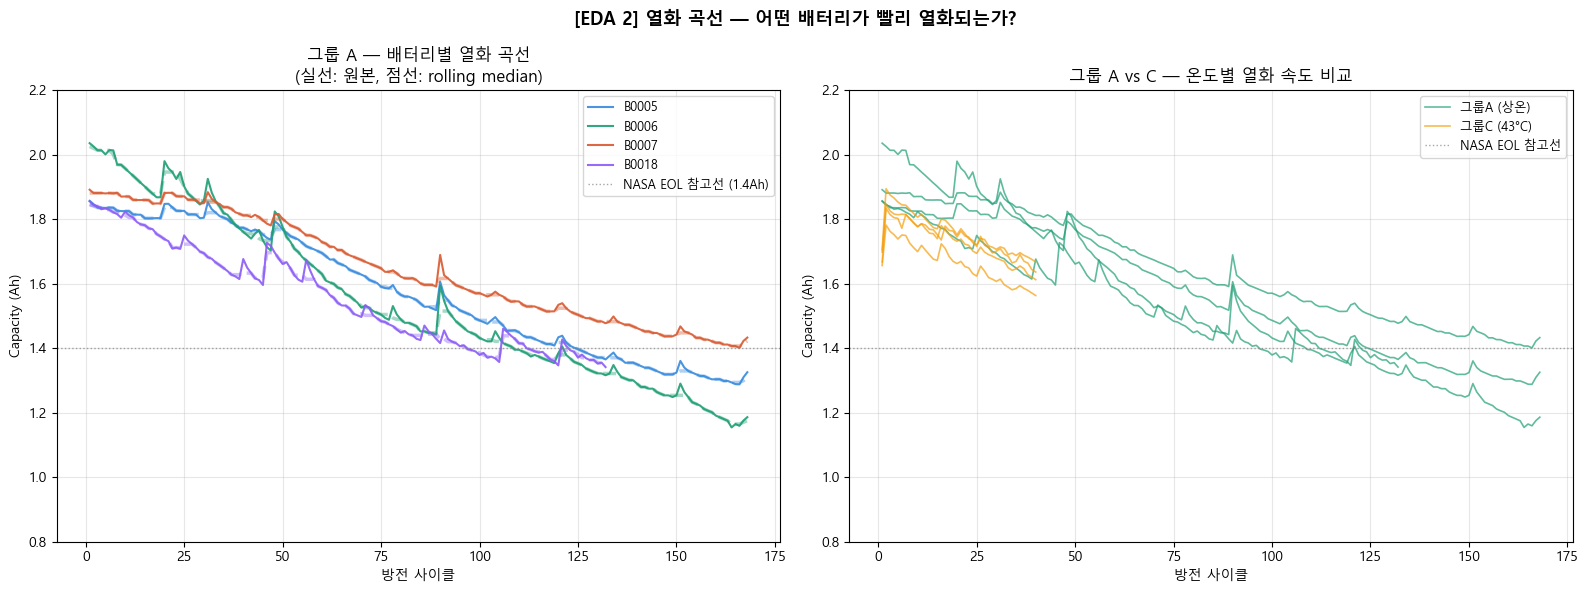

[저장] eda2_degradation_curve.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 왼쪽: 그룹 A 열화 곡선
for bid in sorted(df_A_valid['battery_id'].unique()):
    b_data = df_A_valid[df_A_valid['battery_id'] == bid]
    color = BATTERY_COLORS.get(bid, 'gray')
    axes[0].plot(b_data['discharge_cycle_no'], b_data['Capacity'],
                 linewidth=1.5, label=bid, color=color, alpha=0.9)
    # rolling median 추가 (잡음 제거)
    rolling = b_data.set_index('discharge_cycle_no')['Capacity'].rolling(
        window=5, center=True, min_periods=1
    ).median()
    axes[0].plot(rolling.index, rolling.values,
                 linewidth=2.5, color=color, alpha=0.4, linestyle='--')
 
axes[0].axhline(y=1.4, color='gray', linestyle=':', linewidth=1,
                label='NASA EOL 참고선 (1.4Ah)', alpha=0.7)
axes[0].set_title('그룹 A — 배터리별 열화 곡선\n(실선: 원본, 점선: rolling median)')
axes[0].set_xlabel('방전 사이클')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.8, 2.2)
 
# 오른쪽: 그룹 A vs C 비교
for bid in sorted(df_A_valid['battery_id'].unique()):
    b_data = df_A_valid[df_A_valid['battery_id'] == bid]
    axes[1].plot(b_data['discharge_cycle_no'], b_data['Capacity'],
                 linewidth=1.2, color=GROUP_COLORS['A'], alpha=0.7,
                 label='그룹A (상온)' if bid == 'B0005' else '_nolegend_')
 
for bid in sorted(df_C_valid['battery_id'].unique()):
    b_data = df_C_valid[df_C_valid['battery_id'] == bid]
    axes[1].plot(b_data['discharge_cycle_no'], b_data['Capacity'],
                 linewidth=1.2, color=GROUP_COLORS['C'], alpha=0.7,
                 label='그룹C (43°C)' if bid == 'B0029' else '_nolegend_')
 
axes[1].axhline(y=1.4, color='gray', linestyle=':', linewidth=1,
                label='NASA EOL 참고선', alpha=0.7)
axes[1].set_title('그룹 A vs C — 온도별 열화 속도 비교')
axes[1].set_xlabel('방전 사이클')
axes[1].set_ylabel('Capacity (Ah)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.8, 2.2)
 
fig.suptitle('[EDA 2] 열화 곡선 — 어떤 배터리가 빨리 열화되는가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda2_degradation_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda2_degradation_curve.png')
 

# 3.  SOH 열화 곡선 비교 (그룹 A vs C)

- 초록 선 / 그룹A (상온)
- 주황 선 / 그룹C (43°C 고온)
- 빨간 점선 / EOL 기준 (SOH 80%)
- 주황 점선 / 주의 기준 (SOH 90%)

 초록 배경: SOH 90% 이상 → 정상 /
주황 배경: SOH 80~90% → 주의 /
빨간 배경: SOH 80% 미만 → 교체 권장

어떤 그룹이 빨간 선을 먼저, 더 많이 넘는지 확인하는 차트

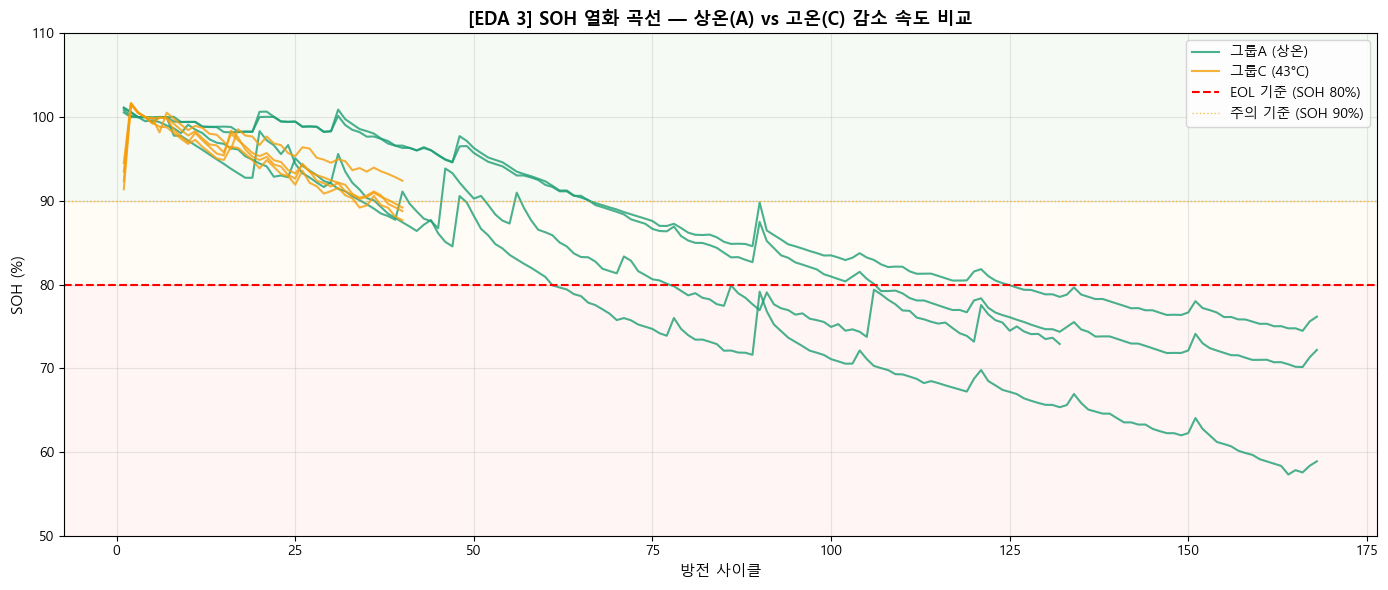

[저장] eda3_soh_curve.png


In [33]:
fig, ax = plt.subplots(figsize=(14, 6))
 
# 그룹 A
for bid in sorted(df_A_valid['battery_id'].unique()):
    b_data = df_A_valid[df_A_valid['battery_id'] == bid]
    ax.plot(b_data['discharge_cycle_no'], b_data['SOH'],
            linewidth=1.5, color=GROUP_COLORS['A'], alpha=0.8,
            label='그룹A (상온)' if bid == 'B0005' else '_nolegend_')
 
# 그룹 C
for bid in sorted(df_C_valid['battery_id'].unique()):
    b_data = df_C_valid[df_C_valid['battery_id'] == bid]
    ax.plot(b_data['discharge_cycle_no'], b_data['SOH'],
            linewidth=1.5, color=GROUP_COLORS['C'], alpha=0.8,
            label='그룹C (43°C)' if bid == 'B0029' else '_nolegend_')
 
ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5,
           label='EOL 기준 (SOH 80%)')
ax.axhline(y=90, color='orange', linestyle=':', linewidth=1,
           label='주의 기준 (SOH 90%)', alpha=0.7)
 
# SOH 구간 색상
ax.axhspan(0, 80, alpha=0.04, color='red')
ax.axhspan(80, 90, alpha=0.04, color='orange')
ax.axhspan(90, 110, alpha=0.04, color='green')
 
ax.set_xlabel('방전 사이클', fontsize=11)
ax.set_ylabel('SOH (%)', fontsize=11)
ax.set_title('[EDA 3] SOH 열화 곡선 — 상온(A) vs 고온(C) 감소 속도 비교',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(50, 110)
 
plt.tight_layout()
plt.savefig('eda3_soh_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda3_soh_curve.png')

# 4. Re·Rct 추이 — 내부저항 변화
내부저항이 SOH보다 먼저 올라가는가?

- 왼쪽 y축 (색깔 선): SOH (%) → 점점 낮아져야 정상
- 오른쪽 y축 (빨강·주황 선): Re, Rct (Ω) → 노화될수록 높아짐

배터리 고유 색상SOH (%)빨간 실선 / Re — 전해질 저항주황 점선/ Rct — 전하전달 저항

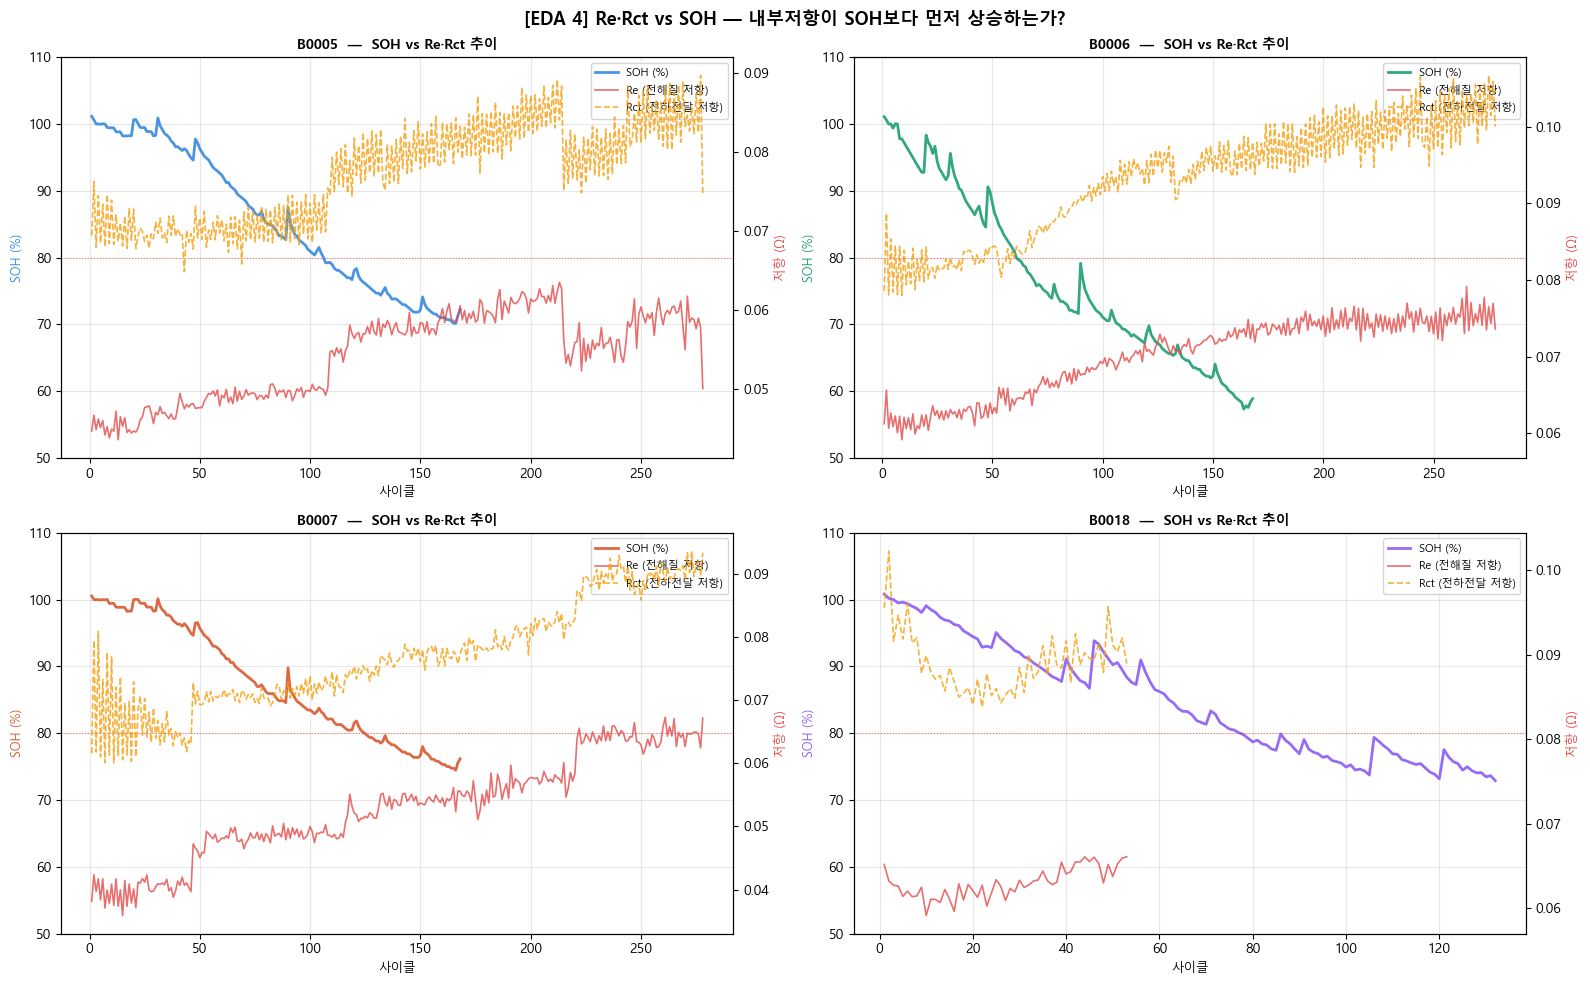

[저장] eda4_re_rct_vs_soh.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
for idx, bid in enumerate(sorted(df_imp_A['battery_id'].unique())):
    row, col = idx // 2, idx % 2
    ax = axes[row][col]
 
    b_imp = df_imp_A[df_imp_A['battery_id'] == bid].copy()
    b_dis = df_A_valid[df_A_valid['battery_id'] == bid].copy()
 
    color = BATTERY_COLORS.get(bid, 'gray')
 
    # Re·Rct (왼쪽 y축)
    ax2 = ax.twinx()
    ax2.plot(b_imp['imp_cycle_no'], b_imp['Re'],
             color='#E24B4A', linewidth=1.2, alpha=0.8, label='Re (전해질 저항)')
    ax2.plot(b_imp['imp_cycle_no'], b_imp['Rct'],
             color='#F59E0B', linewidth=1.2, alpha=0.8, linestyle='--',
             label='Rct (전하전달 저항)')
    ax2.set_ylabel('저항 (Ω)', color='#E24B4A', fontsize=9)
 
    # SOH (오른쪽 y축)
    ax.plot(b_dis['discharge_cycle_no'], b_dis['SOH'],
            color=color, linewidth=2, alpha=0.9, label='SOH (%)')
    ax.axhline(y=80, color='red', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_ylabel('SOH (%)', color=color, fontsize=9)
    ax.set_xlabel('사이클', fontsize=9)
    ax.set_title(f'{bid}  —  SOH vs Re·Rct 추이', fontsize=10, fontweight='bold')
    ax.set_ylim(50, 110)
 
    # 범례 통합
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
 
fig.suptitle('[EDA 4] Re·Rct vs SOH — 내부저항이 SOH보다 먼저 상승하는가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda4_re_rct_vs_soh.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda4_re_rct_vs_soh.png')

# 5. Re·Rct vs SOH 산점도 
 Re·Rct와 SOH는 얼마나 연관되어 있는가?

- x축: Re 또는 Rct 값 (저항)
- y축: SOH (%)
- 빨간 점선: 추세선

산점도에서 점들이 오른쪽 아래로 모이면? / 
저항이 올라갈수록 SOH가 낮아진다 = 음의 상관관계 /
두 값이 함께 움직이는 정도를 -1~+1로 나타낸 수치 /
값 범위의미-1에 가까움강한 음의 상관 (한쪽↑ → 다른쪽↓)0에 가까움관계 없음+1에 가까움강한 양의 상관 

- 결과: Re-SOH r=-0.72, Rct-SOH r=-0.76
- → 내부저항이 올라갈수록 SOH가 낮아지는 강한 음의 상관 확인!

[6] 매핑된 행 수: 557


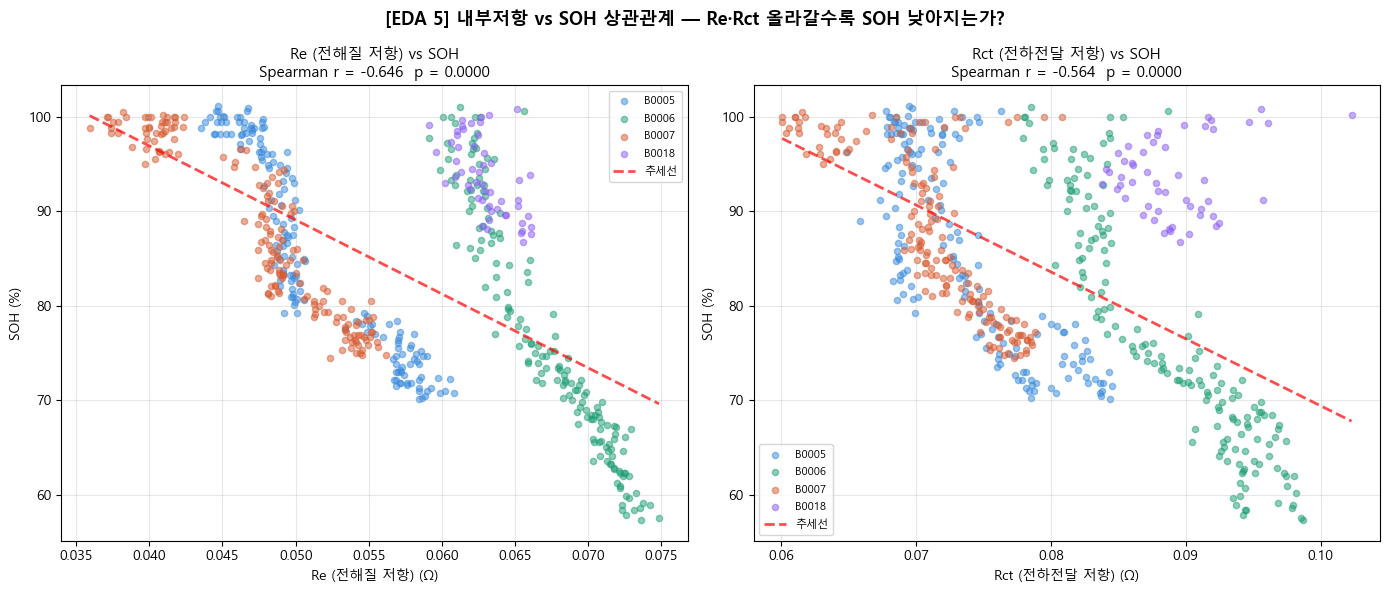

[저장] eda5_correlation.png


In [35]:
imp_A_ranked = df_imp_A.copy()
imp_A_ranked['cycle_rank'] = (
    imp_A_ranked.groupby('battery_id')['imp_cycle_no']
    .rank(method='first').astype(int)
)
 
dis_A_ranked = df_A_valid.copy()
dis_A_ranked['cycle_rank'] = (
    dis_A_ranked.groupby('battery_id')['discharge_cycle_no']
    .rank(method='first').astype(int)
)
 
# Re·Rct만 선택해서 merge (컬럼 충돌 방지)
merged = dis_A_ranked.merge(
    imp_A_ranked[['battery_id', 'cycle_rank', 'Re', 'Rct']],
    on=['battery_id', 'cycle_rank'],
    how='inner',
    suffixes=('_dis', '_imp')
)
 
# ★ impedance 쪽 Re·Rct로 교체
merged['Re']  = merged['Re_imp']
merged['Rct'] = merged['Rct_imp']
merged = merged.drop(
    columns=[c for c in merged.columns
             if c.endswith('_dis') or c.endswith('_imp')],
    errors='ignore'
)
merged = merged.dropna(subset=['SOH', 'Re', 'Rct'])
 
print(f"[6] 매핑된 행 수: {len(merged)}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, col, name in zip(
    axes,
    ['Re', 'Rct'],
    ['Re (전해질 저항)', 'Rct (전하전달 저항)']
):
    for bid in sorted(merged['battery_id'].unique()):
        b = merged[merged['battery_id'] == bid]
        color = BATTERY_COLORS.get(bid, 'gray')
        ax.scatter(b[col], b['SOH'], alpha=0.5, s=20, color=color, label=bid)
 
    # 추세선
    x = merged[col].values
    y = merged['SOH'].values
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            'r--', linewidth=2, alpha=0.7, label='추세선')
 
    from scipy.stats import spearmanr
    corr_r, corr_p = spearmanr(x, y)
    ax.set_xlabel(f'{name} (Ω)', fontsize=10)
    ax.set_ylabel('SOH (%)', fontsize=10)
    ax.set_title(f'{name} vs SOH\nSpearman r = {corr_r:.3f}  p = {corr_p:.4f}',
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
 
fig.suptitle('[EDA 5] 내부저항 vs SOH 상관관계 — Re·Rct 올라갈수록 SOH 낮아지는가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda5_correlation.png')

# 6. 도별 평균 수명 비교 바차트
고온이 수명을 얼마나 단축하는가?

- 왼쪽: 배터리별 EOL 도달 사이클 수 (높을수록 오래 버팀)
- 오른쪽: 그룹별 평균 EOL + 오차막대(표준편차)

그룹C(43°C)는 EOL 미달!

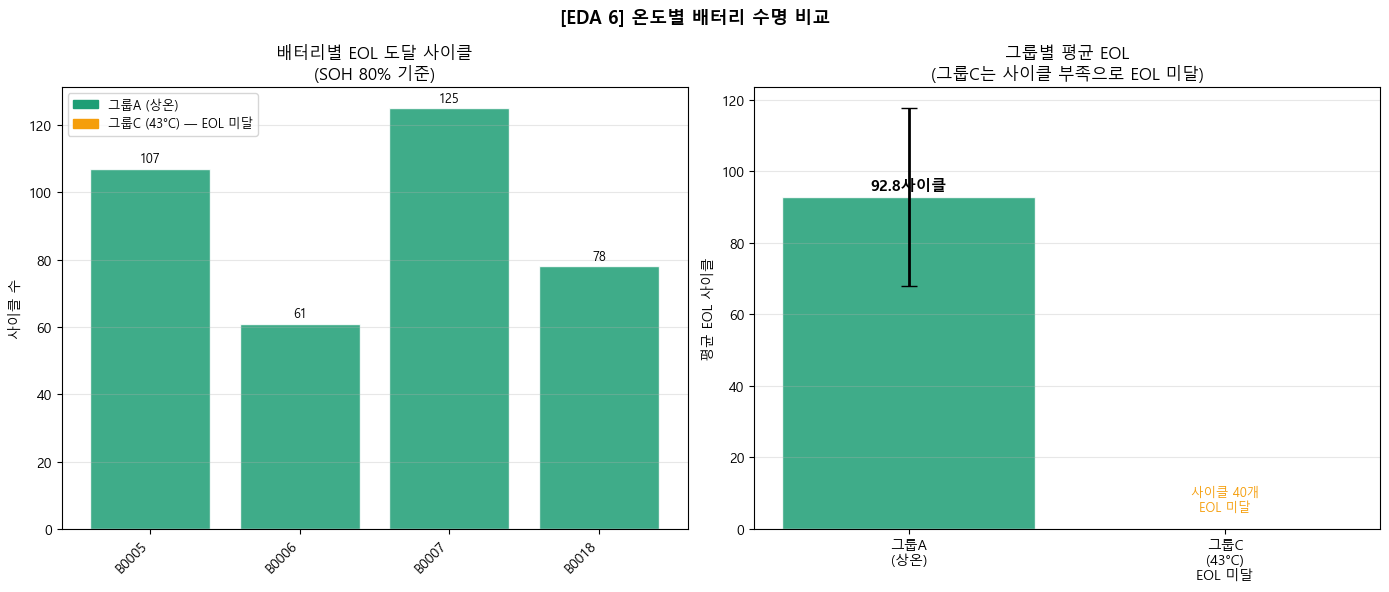

[저장] eda6_lifetime_comparison.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
eol_data = []
for df_grp, grp_label in [(df_A_valid, 'A'), (df_C_valid, 'C')]:
    for bid in df_grp['battery_id'].unique():
        b    = df_grp[df_grp['battery_id'] == bid]
        eol  = b[b['SOH'] < 80]['discharge_cycle_no'].min()
        total = b['discharge_cycle_no'].max()
        temp  = b['ambient_temperature'].mode()[0]
        eol_data.append({
            'battery_id': bid, 'group': grp_label,
            'eol_cycle': eol, 'total_cycle': total, 'temperature': temp,
        })
 
eol_df = pd.DataFrame(eol_data)
eol_A  = eol_df[eol_df['group'] == 'A']['eol_cycle'].dropna().values
eol_C  = eol_df[eol_df['group'] == 'C']['eol_cycle'].dropna().values
 
import matplotlib.patches as mpatches
colors_bar = [GROUP_COLORS[g] for g in eol_df['group']]
bars = axes[0].bar(eol_df['battery_id'], eol_df['eol_cycle'],
                   color=colors_bar, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, eol_df['eol_cycle']):
    if pd.notna(val):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+1, f'{int(val)}',
                     ha='center', va='bottom', fontsize=9)
 
axes[0].set_title('배터리별 EOL 도달 사이클\n(SOH 80% 기준)')
axes[0].set_ylabel('사이클 수')
axes[0].set_xticklabels(eol_df['battery_id'], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(handles=[
    mpatches.Patch(color=GROUP_COLORS['A'], label='그룹A (상온)'),
    mpatches.Patch(color=GROUP_COLORS['C'], label='그룹C (43°C) — EOL 미달'),
], fontsize=9)
 
# 그룹A만 평균 EOL 표시 (그룹C는 EOL 미달)
if len(eol_A) > 0:
    axes[1].bar(['그룹A\n(상온)'], [np.mean(eol_A)],
                color=GROUP_COLORS['A'], alpha=0.85, edgecolor='white',
                yerr=[np.std(eol_A)], capsize=6, error_kw={'linewidth':2})
    axes[1].text(0, np.mean(eol_A)+2, f'{np.mean(eol_A):.1f}사이클',
                 ha='center', fontsize=11, fontweight='bold')
 
axes[1].bar(['그룹C\n(43°C)\nEOL 미달'], [0],
            color=GROUP_COLORS['C'], alpha=0.4, edgecolor='white')
axes[1].text(1, 5, '사이클 40개\nEOL 미달', ha='center',
             fontsize=9, color=GROUP_COLORS['C'])
axes[1].set_ylabel('평균 EOL 사이클')
axes[1].set_title('그룹별 평균 EOL\n(그룹C는 사이클 부족으로 EOL 미달)')
axes[1].grid(axis='y', alpha=0.3)
 
fig.suptitle('[EDA 6] 온도별 배터리 수명 비교',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda6_lifetime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda6_lifetime_comparison.png')

# 7. 이상 배터리 패턴 (그룹 F·G·H·I)
비정상 패턴이 어떻게 생겼는가?

- 정상: 선이 완만하게 천천히 내려감
- 급락: 갑자기 0 근처로 뚝 떨어짐
- 불규칙: 올라갔다 내려갔다 반복
- 조기 종료: 다른 배터리보다 훨씬 일찍 끊김

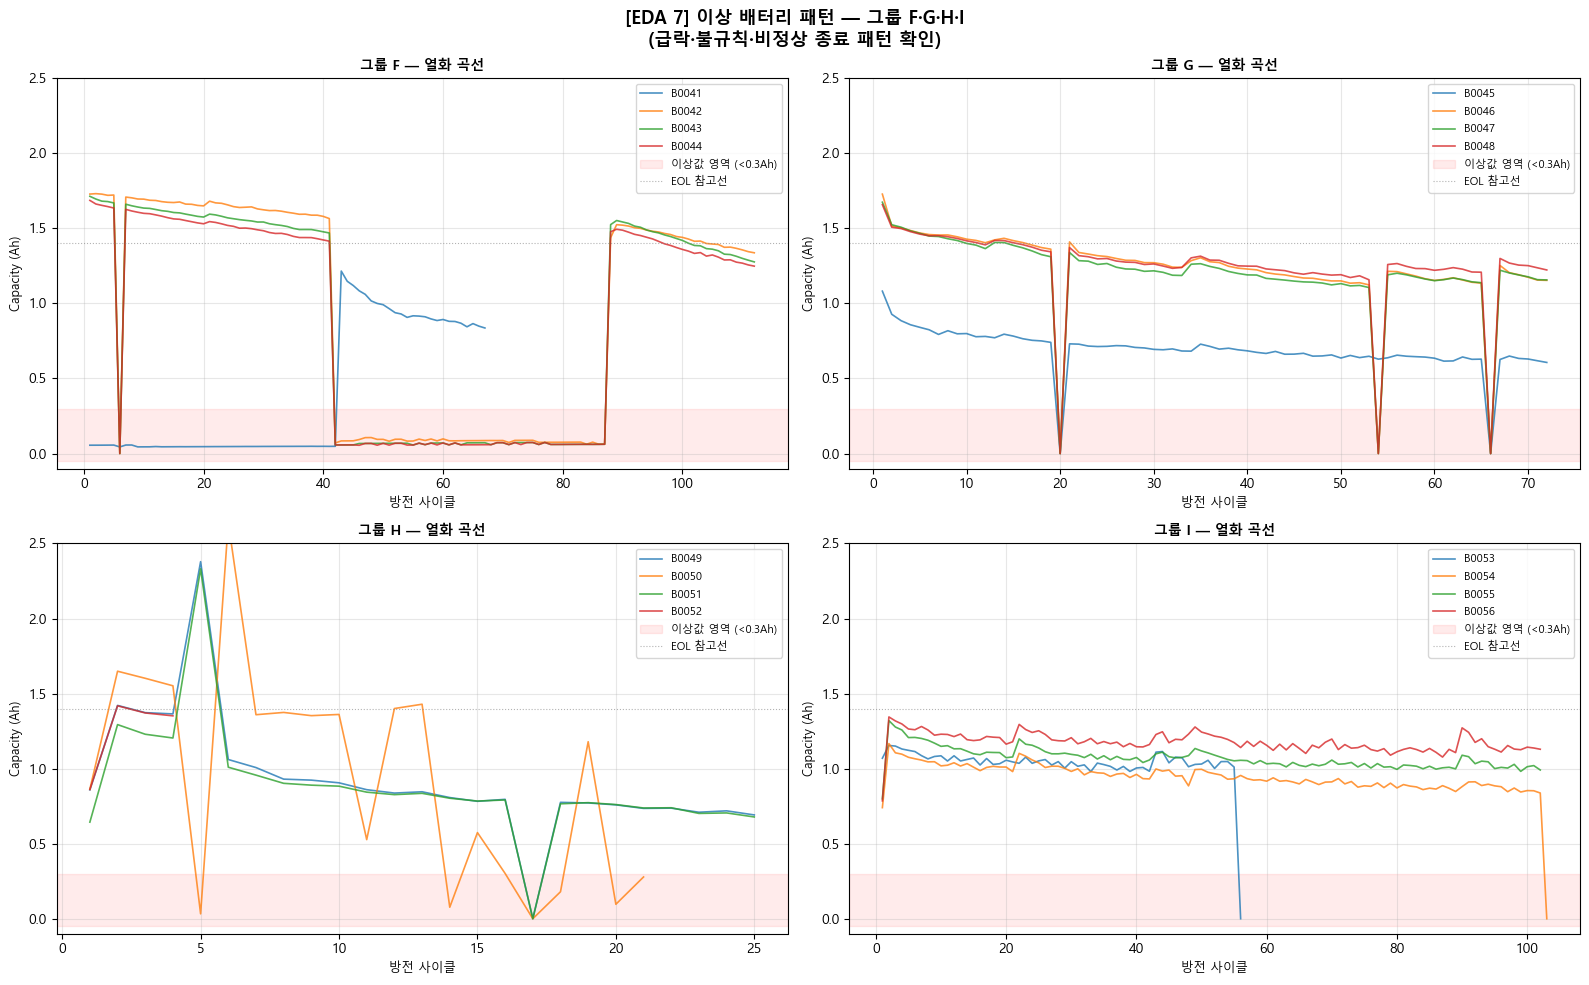

[저장] eda7_anomaly_pattern.png


In [37]:
df_anom = df_anomaly.copy()
df_anom['Capacity'] = pd.to_numeric(df_anom['Capacity'], errors='coerce')
 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
for idx, grp in enumerate(['F', 'G', 'H', 'I']):
    row, col = idx // 2, idx % 2
    ax = axes[row][col]
    grp_data = df_anom[df_anom['group'] == grp]
 
    for bid in sorted(grp_data['battery_id'].unique()):
        b = grp_data[grp_data['battery_id'] == bid]
        ax.plot(b['discharge_cycle_no'], b['Capacity'],
                linewidth=1.2, alpha=0.8, label=bid)
 
    ax.axhspan(-0.05, 0.3, alpha=0.08, color='red', label='이상값 영역 (<0.3Ah)')
    ax.axhline(y=1.4, color='gray', linestyle=':', linewidth=0.8,
               label='EOL 참고선', alpha=0.6)
    ax.set_title(f'그룹 {grp} — 열화 곡선',
                 fontsize=10, fontweight='bold',
                 color=GROUP_COLORS.get(grp, 'black'))
    ax.set_xlabel('방전 사이클', fontsize=9)
    ax.set_ylabel('Capacity (Ah)', fontsize=9)
    ax.set_ylim(-0.1, 2.5)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
 
fig.suptitle('[EDA 7] 이상 배터리 패턴 — 그룹 F·G·H·I\n'
             '(급락·불규칙·비정상 종료 패턴 확인)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda7_anomaly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda7_anomaly_pattern.png')

# 8. 상관관계 히트맵


히트맵 데이터: 305행


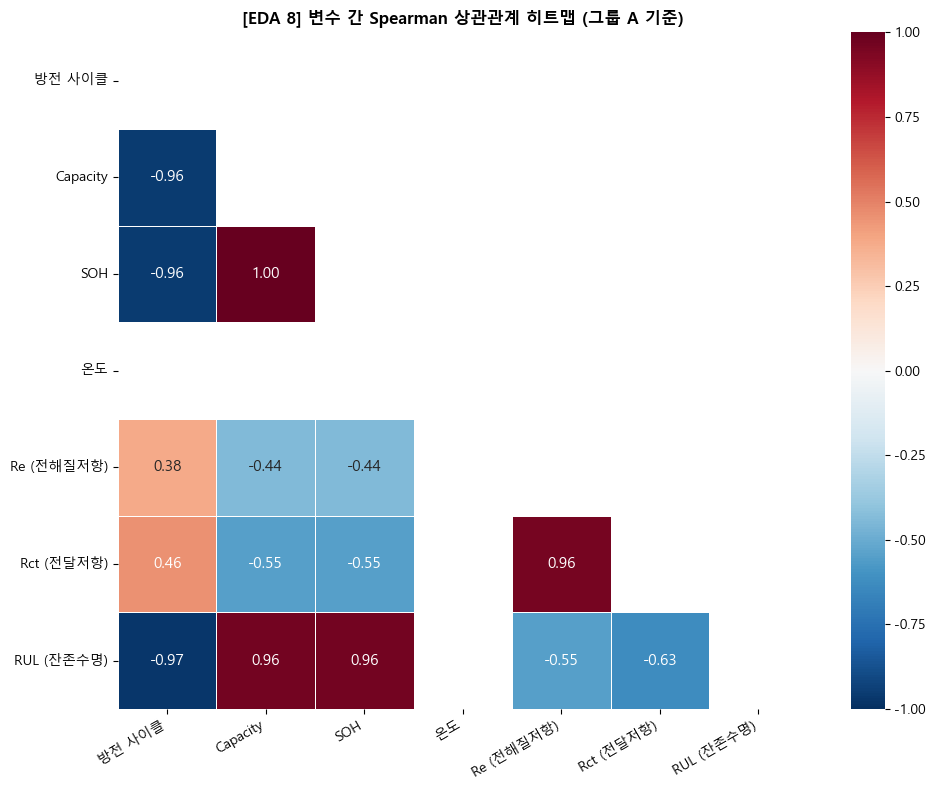

[저장] eda8_correlation_heatmap.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
 
# impedance 사이클 근사 매핑
# imp_cycle_no를 2로 나눠 discharge_cycle_raw에 근사 매핑
imp_A_mapped = df_imp_A.copy()
imp_A_mapped['discharge_cycle_raw'] = ((imp_A_mapped['imp_cycle_no'] + 1) // 2)
 
imp_agg = (
    imp_A_mapped.groupby(['battery_id', 'discharge_cycle_raw'])[['Re', 'Rct']]
    .mean()
    .reset_index()
    .rename(columns={'Re': 'Re_val', 'Rct': 'Rct_val'})
)
 
heatmap_df = df_A_valid.merge(
    imp_agg, on=['battery_id', 'discharge_cycle_raw'], how='left'
)
heatmap_df['Re']  = heatmap_df['Re_val']
heatmap_df['Rct'] = heatmap_df['Rct_val']
 
corr_cols = ['discharge_cycle_raw', 'Capacity', 'SOH_nominal',
             'ambient_temperature', 'Re', 'Rct', 'RUL']
heatmap_df = heatmap_df[corr_cols].dropna()
 
print(f"히트맵 데이터: {len(heatmap_df)}행")
 
corr_matrix = heatmap_df.corr(method='spearman')
 
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
 
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    mask=mask, ax=ax,
    linewidths=0.5,
    annot_kws={'size': 11}
)
 
korean_labels = {
    'discharge_cycle_raw': '방전 사이클',
    'Capacity': 'Capacity',
    'SOH_nominal': 'SOH',
    'ambient_temperature': '온도',
    'Re': 'Re (전해질저항)',
    'Rct': 'Rct (전달저항)',
    'RUL': 'RUL (잔존수명)',
}
ax.set_xticklabels(
    [korean_labels.get(c, c) for c in corr_matrix.columns],
    rotation=30, ha='right', fontsize=10
)
ax.set_yticklabels(
    [korean_labels.get(c, c) for c in corr_matrix.index],
    rotation=0, fontsize=10
)
ax.set_title('[EDA 8] 변수 간 Spearman 상관관계 히트맵 (그룹 A 기준)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] eda8_correlation_heatmap.png')
 

In [11]:
print("discharge start_time 샘플:")
print(df_A_valid['start_time'].head(3).tolist())

print("\nimpedance start_time 샘플:")
print(df_imp_A['start_time'].head(3).tolist())

discharge start_time 샘플:
[Timestamp('2008-04-02 15:25:41'), Timestamp('2008-04-02 19:43:48'), Timestamp('2008-04-03 00:01:06')]

impedance start_time 샘플:
['2008-04-18 20:55:29', '2008-04-18 22:39:16', '2008-04-19 02:14:27']


In [39]:
from scipy.stats import spearmanr
 
r_re,  p_re  = spearmanr(merged['Re'],  merged['SOH'])
r_rct, p_rct = spearmanr(merged['Rct'], merged['SOH'])
 
print("\n" + "=" * 55)
print("EDA 완료 — 핵심 발견 요약")
print("=" * 55)
 
if len(eol_A) > 0:
    print(f"그룹A (상온)  평균 EOL : {np.mean(eol_A):.1f} 사이클")
print(f"그룹C (43°C) EOL     : 미달 (40사이클에서 실험 종료)")
print(f"\nRe-SOH  Spearman r : {r_re:.3f}  (p={p_re:.4f})")
print(f"Rct-SOH Spearman r : {r_rct:.3f}  (p={p_rct:.4f})")
print(f"→ {'음의 상관 확인 (저항↑ → SOH↓)' if r_re < -0.3 else '추가 확인 필요'}")
 
print("\n저장된 차트 목록:")
for name in [
    'eda1_soh_distribution.png    — SOH 분포 박스플롯',
    'eda2_degradation_curve.png   — 열화 곡선',
    'eda3_soh_curve.png           — SOH 열화 곡선 비교',
    'eda4_re_rct_vs_soh.png       — Re·Rct vs SOH 추이',
    'eda5_correlation.png         — 내부저항 vs SOH 산점도',
    'eda6_lifetime_comparison.png — 온도별 수명 비교',
    'eda7_anomaly_pattern.png     — 이상 배터리 패턴',
    'eda8_correlation_heatmap.png — 상관관계 히트맵',
]:
    print(f"  {name}")


EDA 완료 — 핵심 발견 요약
그룹A (상온)  평균 EOL : 92.8 사이클
그룹C (43°C) EOL     : 미달 (40사이클에서 실험 종료)

Re-SOH  Spearman r : -0.646  (p=0.0000)
Rct-SOH Spearman r : -0.564  (p=0.0000)
→ 음의 상관 확인 (저항↑ → SOH↓)

저장된 차트 목록:
  eda1_soh_distribution.png    — SOH 분포 박스플롯
  eda2_degradation_curve.png   — 열화 곡선
  eda3_soh_curve.png           — SOH 열화 곡선 비교
  eda4_re_rct_vs_soh.png       — Re·Rct vs SOH 추이
  eda5_correlation.png         — 내부저항 vs SOH 산점도
  eda6_lifetime_comparison.png — 온도별 수명 비교
  eda7_anomaly_pattern.png     — 이상 배터리 패턴
  eda8_correlation_heatmap.png — 상관관계 히트맵


# 통계검증

In [5]:
print("\n" + "=" * 55)
print("[2] 정규성 검정 (Shapiro-Wilk)")
print("=" * 55)
print("귀무가설: 데이터가 정규분포를 따른다")
print("p > 0.05 → 정규성 만족 / p ≤ 0.05 → 정규성 불만족\n")
 
normality_results = {}
groups = {
    '그룹A SOH': df_A_valid['SOH'].dropna().values,
    '그룹C SOH': df_C_valid['SOH'].dropna().values,
    '그룹A EOL': eol_A['eol_cycle'].dropna().values,
    '그룹C EOL': eol_C['eol_cycle'].dropna().values,
}
 
for name, data in groups.items():
    if len(data) >= 3:
        stat, p = shapiro(data)
        normal = "정규성 만족" if p > 0.05 else "정규성 불만족"
        print(f"{name:15s}: W={stat:.4f}, p={p:.4f}  →  {normal}")
        normality_results[name] = p > 0.05
    else:
        print(f"{name:15s}: 샘플 수 부족")
        normality_results[name] = False
 
all_normal = all(normality_results.values())
print(f"\n→ 검정 방법 선택: {'ANOVA (모수)' if all_normal else 'Kruskal-Wallis (비모수)'}")


[2] 정규성 검정 (Shapiro-Wilk)
귀무가설: 데이터가 정규분포를 따른다
p > 0.05 → 정규성 만족 / p ≤ 0.05 → 정규성 불만족

그룹A SOH        : W=0.9612, p=0.0000  →  정규성 불만족
그룹C SOH        : W=0.9774, p=0.0100  →  정규성 불만족
그룹A EOL        : W=0.9650, p=0.8102  →  정규성 만족
그룹C EOL        : 샘플 수 부족

→ 검정 방법 선택: Kruskal-Wallis (비모수)



[3] 온도별 수명 차이 검정
귀무가설: 상온(A)과 고온(C)의 EOL 사이클 평균이 같다
p < 0.05 → 유의미한 차이 있음

그룹A EOL — 평균: 92.8, 표준편차: 24.8, n=4
그룹C EOL — 평균: nan, 표준편차: nan, n=0

샘플 수 부족으로 검정 불가


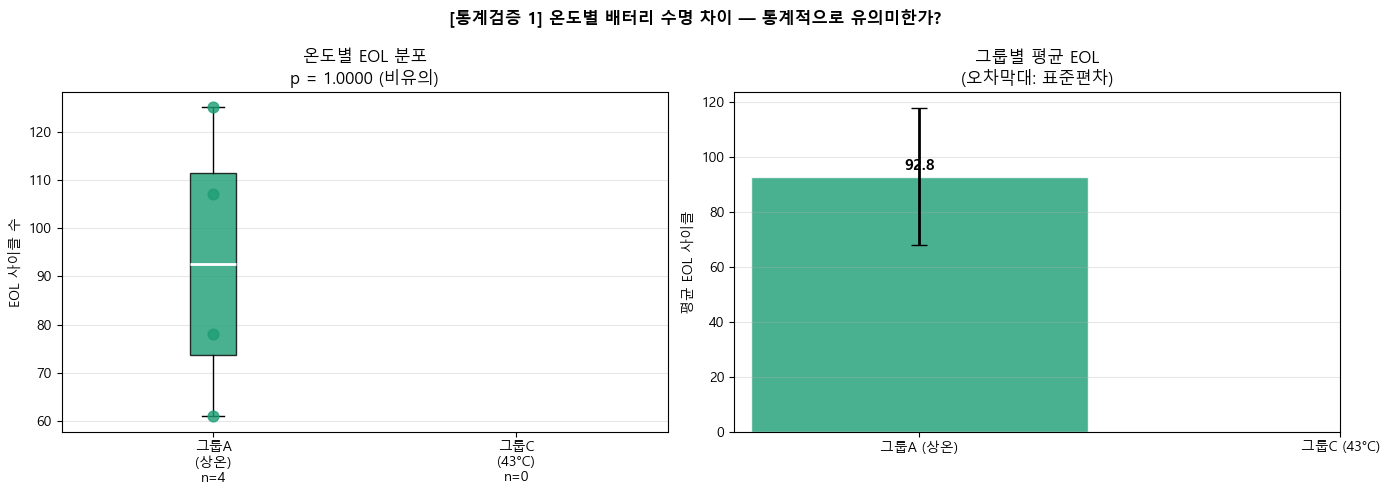

[저장] stat1_temperature_test.png


In [ ]:
print("\n" + "=" * 55)
print("[3] 온도별 수명 차이 검정")
print("=" * 55)
print("귀무가설: 상온(A)과 고온(C)의 EOL 사이클 평균이 같다")
print("p < 0.05 → 유의미한 차이 있음\n")
 
grp_A_eol = eol_A['eol_cycle'].dropna().values
grp_C_eol = eol_C['eol_cycle'].dropna().values
 
print(f"그룹A EOL — 평균: {np.mean(grp_A_eol):.1f}, 표준편차: {np.std(grp_A_eol):.1f}, n={len(grp_A_eol)}")
print(f"그룹C EOL — 평균: {np.mean(grp_C_eol):.1f}, 표준편차: {np.std(grp_C_eol):.1f}, n={len(grp_C_eol)}")
 
# 등분산 검정 (Levene)
if len(grp_A_eol) >= 2 and len(grp_C_eol) >= 2:
    lev_stat, lev_p = levene(grp_A_eol, grp_C_eol)
    print(f"\nLevene 등분산 검정: F={lev_stat:.4f}, p={lev_p:.4f}")
    print(f"→ {'등분산 가정 만족' if lev_p > 0.05 else '등분산 가정 불만족'}")
 
# 주 검정
if all_normal and len(grp_A_eol) >= 2 and len(grp_C_eol) >= 2:
    # ANOVA
    f_stat, p_anova = f_oneway(grp_A_eol, grp_C_eol)
    print(f"\nOne-way ANOVA: F={f_stat:.4f}, p={p_anova:.4f}")
    sig = "✅ 유의미한 차이 있음 (p < 0.05)" if p_anova < 0.05 else "❌ 유의미한 차이 없음"
    print(f"→ {sig}")
    test_p = p_anova
else:
    # Kruskal-Wallis (비모수)
    if len(grp_A_eol) >= 2 and len(grp_C_eol) >= 2:
        kw_stat, kw_p = kruskal(grp_A_eol, grp_C_eol)
        print(f"\nKruskal-Wallis: H={kw_stat:.4f}, p={kw_p:.4f}")
        sig = "✅ 유의미한 차이 있음 (p < 0.05)" if kw_p < 0.05 else "❌ 유의미한 차이 없음"
        print(f"→ {sig}")
        test_p = kw_p
    else:
        print("\n샘플 수 부족으로 검정 불가")
        test_p = 1.0
 
# Mann-Whitney U (2그룹 비모수)
if len(grp_A_eol) >= 2 and len(grp_C_eol) >= 2:
    mw_stat, mw_p = mannwhitneyu(grp_A_eol, grp_C_eol, alternative='two-sided')
    print(f"\nMann-Whitney U (보조): U={mw_stat:.1f}, p={mw_p:.4f}")
 
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# 왼쪽: EOL 분포 비교
data_plot = [grp_A_eol, grp_C_eol]
labels_plot = [f'그룹A\n(상온)\nn={len(grp_A_eol)}', f'그룹C\n(43°C)\nn={len(grp_C_eol)}']
bp = axes[0].boxplot(data_plot, labels=labels_plot, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))
colors_bp = ['#1D9E75', '#F59E0B']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
 
# 개별 데이터 포인트
for i, (data, color) in enumerate(zip(data_plot, colors_bp), 1):
    axes[0].scatter([i]*len(data), data, color=color, alpha=0.8, s=60, zorder=5)
 
axes[0].set_ylabel('EOL 사이클 수')
axes[0].set_title(f'온도별 EOL 분포\np = {test_p:.4f} {"(유의미)" if test_p < 0.05 else "(비유의)"}')
axes[0].grid(axis='y', alpha=0.3)
 
# 오른쪽: 평균 + 신뢰구간
means = [np.mean(grp_A_eol), np.mean(grp_C_eol)]
stds  = [np.std(grp_A_eol), np.std(grp_C_eol)]
x_pos = [0, 1]
axes[1].bar(x_pos, means, color=colors_bp, alpha=0.8, edgecolor='white',
            yerr=stds, capsize=6, error_kw={'linewidth':2})
for x, m in zip(x_pos, means):
    axes[1].text(x, m + max(stds)*0.1, f'{m:.1f}', ha='center',
                 fontsize=11, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['그룹A (상온)', '그룹C (43°C)'])
axes[1].set_ylabel('평균 EOL 사이클')
axes[1].set_title('그룹별 평균 EOL\n(오차막대: 표준편차)')
axes[1].grid(axis='y', alpha=0.3)
 
fig.suptitle('[통계검증 1] 온도별 배터리 수명 차이 — 통계적으로 유의미한가?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stat1_temperature_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat1_temperature_test.png')


[3] 온도별 열화 속도 차이 검정 (SOH 감소량 기준)
※ 그룹C는 사이클 40개로 SOH 80% 미달
   → EOL 비교 대신 동일 구간(1~40사이클) SOH 감소량 비교

배터리별 SOH 감소량 (1~40 사이클):
battery_id group  temperature  soh_start  soh_end  soh_drop
     B0005     A           24     101.15    96.60      4.55
     B0006     A           24     101.09    87.44     13.65
     B0007     A           24     100.55    96.32      4.23
     B0018     A           24     100.84    91.11      9.73
     B0029     C           43      93.49    88.78      4.71
     B0030     C           43      94.54    89.21      5.33
     B0031     C           43      92.37    92.40     -0.03
     B0032     C           43      91.39    87.69      3.70

그룹A (상온)  평균 SOH 감소: 8.04%  n=4
그룹C (43°C)  평균 SOH 감소: 3.43%  n=4

정규성 검정: 그룹A p=0.3464 / 그룹C p=0.2528

Mann-Whitney U 검정: U=12.0, p=0.3429
→ 유의미한 차이 없음 (p ≥ 0.05)


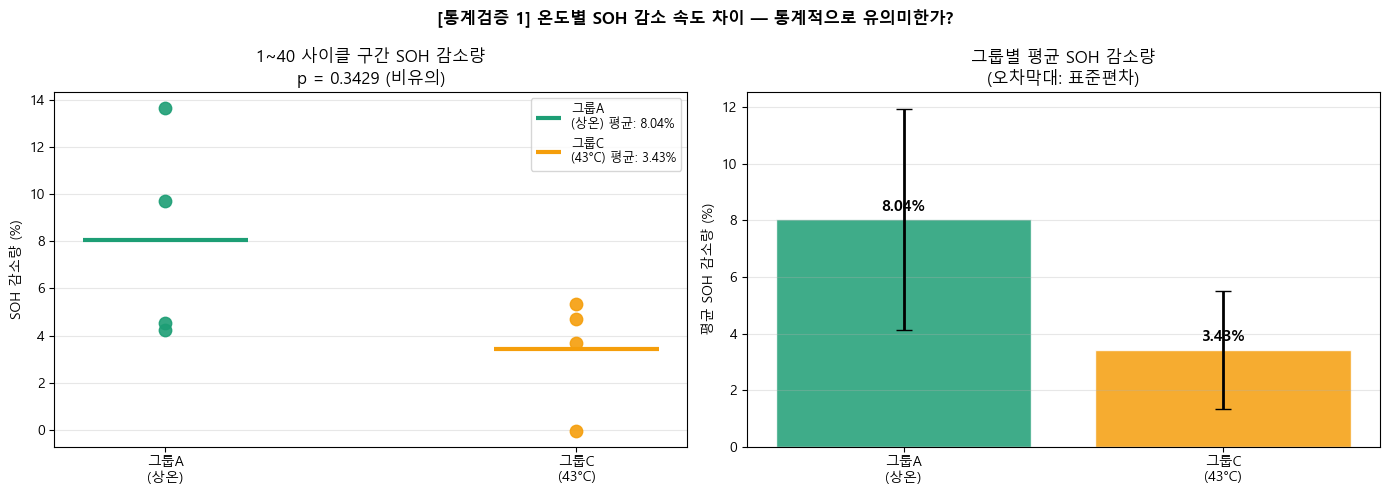

[저장] stat1_temperature_test.png


In [10]:
print("\n" + "=" * 55)
print("[3] 온도별 열화 속도 차이 검정 (SOH 감소량 기준)")
print("=" * 55)
print("※ 그룹C는 사이클 40개로 SOH 80% 미달")
print("   → EOL 비교 대신 동일 구간(1~40사이클) SOH 감소량 비교\n")

MAX_CYCLE = 40

drop_data = []
for df_grp, grp_label in [(df_A_valid, 'A'), (df_C_valid, 'C')]:
    for bid in sorted(df_grp['battery_id'].unique()):
        b = df_grp[
            (df_grp['battery_id']==bid) &
            (df_grp['cap_flag']=='valid')
        ].sort_values('discharge_cycle_no')

        soh_start   = b.iloc[0]['SOH'] if len(b) > 0 else np.nan
        soh_end_row = b[b['discharge_cycle_no'] == MAX_CYCLE]
        soh_end     = soh_end_row.iloc[0]['SOH'] if len(soh_end_row) > 0 else np.nan
        temp        = b['ambient_temperature'].mode()[0] if len(b) > 0 else np.nan

        drop_data.append({
            'battery_id': bid,
            'group'     : grp_label,
            'temperature': temp,
            'soh_start' : round(soh_start, 2) if pd.notna(soh_start) else np.nan,
            'soh_end'   : round(soh_end, 2)   if pd.notna(soh_end)   else np.nan,
            'soh_drop'  : round(soh_start - soh_end, 2)
                          if pd.notna(soh_start) and pd.notna(soh_end) else np.nan,
        })

drop_df = pd.DataFrame(drop_data).dropna(subset=['soh_drop'])

print("배터리별 SOH 감소량 (1~40 사이클):")
print(drop_df.to_string(index=False))

grp_A_drop = drop_df[drop_df['group']=='A']['soh_drop'].values
grp_C_drop = drop_df[drop_df['group']=='C']['soh_drop'].values

print(f"\n그룹A (상온)  평균 SOH 감소: {np.mean(grp_A_drop):.2f}%  n={len(grp_A_drop)}")
print(f"그룹C (43°C)  평균 SOH 감소: {np.mean(grp_C_drop):.2f}%  n={len(grp_C_drop)}")

# 정규성 검정
_, p_norm_A = shapiro(grp_A_drop)
_, p_norm_C = shapiro(grp_C_drop)
print(f"\n정규성 검정: 그룹A p={p_norm_A:.4f} / 그룹C p={p_norm_C:.4f}")

# Mann-Whitney U (샘플 수 적어서 비모수 적합)
mw_stat, mw_p = mannwhitneyu(grp_A_drop, grp_C_drop, alternative='two-sided')
print(f"\nMann-Whitney U 검정: U={mw_stat:.1f}, p={mw_p:.4f}")
sig = "유의미한 차이 있음 (p < 0.05)" if mw_p < 0.05 else "유의미한 차이 없음 (p ≥ 0.05)"
print(f"→ {sig}")
test_p = mw_p

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 개별 데이터 포인트 + 평균
for i, (grp_label, grp_drop, color, xpos) in enumerate([
    ('그룹A\n(상온)', grp_A_drop, '#1D9E75', 1),
    ('그룹C\n(43°C)', grp_C_drop, '#F59E0B', 2),
]):
    axes[0].scatter([xpos]*len(grp_drop), grp_drop,
                    color=color, s=80, alpha=0.9, zorder=5)
    axes[0].hlines(np.mean(grp_drop), xpos-0.2, xpos+0.2,
                   color=color, linewidth=3, label=f'{grp_label} 평균: {np.mean(grp_drop):.2f}%')

axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['그룹A\n(상온)', '그룹C\n(43°C)'])
axes[0].set_ylabel('SOH 감소량 (%)')
axes[0].set_title(f'1~40 사이클 구간 SOH 감소량\np = {mw_p:.4f} {"(유의미)" if mw_p < 0.05 else "(비유의)"}')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 평균 바차트
means = [np.mean(grp_A_drop), np.mean(grp_C_drop)]
stds  = [np.std(grp_A_drop),  np.std(grp_C_drop)]
axes[1].bar(['그룹A\n(상온)', '그룹C\n(43°C)'],
            means, color=['#1D9E75','#F59E0B'],
            alpha=0.85, edgecolor='white',
            yerr=stds, capsize=6, error_kw={'linewidth':2})
for x, m in enumerate(means):
    axes[1].text(x, m + 0.3, f'{m:.2f}%', ha='center',
                 fontsize=11, fontweight='bold')
axes[1].set_ylabel('평균 SOH 감소량 (%)')
axes[1].set_title('그룹별 평균 SOH 감소량\n(오차막대: 표준편차)')
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('[통계검증 1] 온도별 SOH 감소 속도 차이 — 통계적으로 유의미한가?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stat1_temperature_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat1_temperature_test.png')


[4] 그룹별 SOH 열화 곡선 비교 (1~40 사이클 동일 구간)


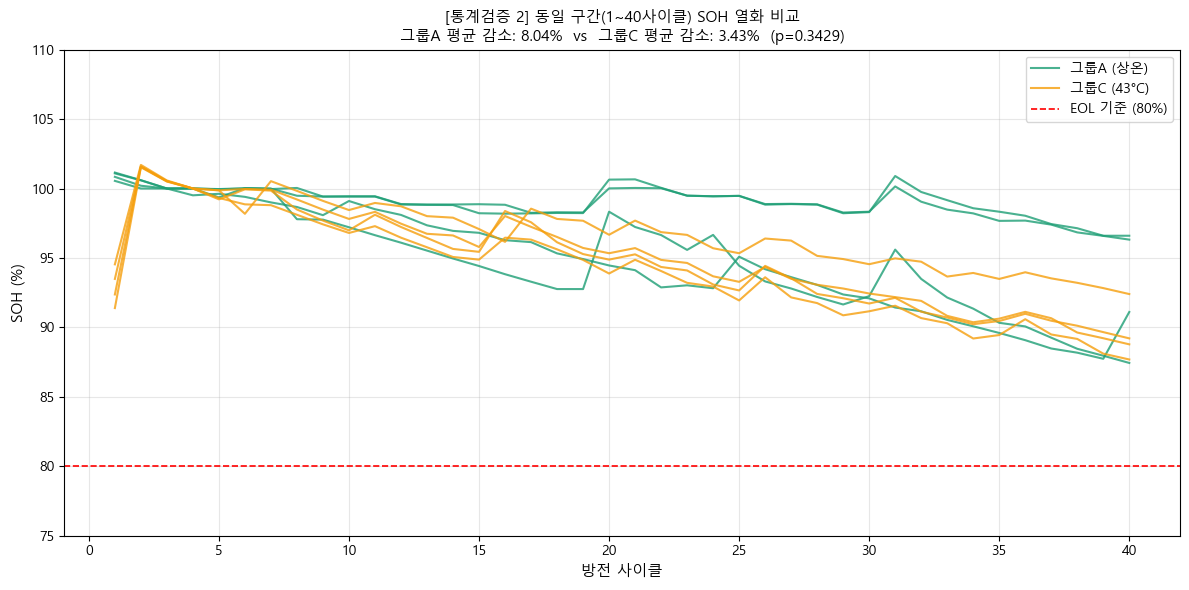

[저장] stat2_soh_curve_comparison.png


In [11]:
print("\n" + "=" * 55)
print("[4] 그룹별 SOH 열화 곡선 비교 (1~40 사이클 동일 구간)")
print("=" * 55)

fig, ax = plt.subplots(figsize=(12, 6))

for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[
        (df_A_valid['battery_id']==bid) &
        (df_A_valid['discharge_cycle_no'] <= MAX_CYCLE) &
        (df_A_valid['cap_flag']=='valid')
    ]
    ax.plot(b['discharge_cycle_no'], b['SOH'],
            color='#1D9E75', linewidth=1.5, alpha=0.8,
            label='그룹A (상온)' if bid=='B0005' else '_nolegend_')

for bid in sorted(df_C_valid['battery_id'].unique()):
    b = df_C_valid[
        (df_C_valid['battery_id']==bid) &
        (df_C_valid['discharge_cycle_no'] <= MAX_CYCLE) &
        (df_C_valid['cap_flag']=='valid')
    ]
    ax.plot(b['discharge_cycle_no'], b['SOH'],
            color='#F59E0B', linewidth=1.5, alpha=0.8,
            label='그룹C (43°C)' if bid=='B0029' else '_nolegend_')

ax.axhline(y=80, color='red', linestyle='--', linewidth=1.2,
           label='EOL 기준 (80%)')
ax.set_xlabel('방전 사이클', fontsize=11)
ax.set_ylabel('SOH (%)', fontsize=11)
ax.set_title(f'[통계검증 2] 동일 구간(1~{MAX_CYCLE}사이클) SOH 열화 비교\n'
             f'그룹A 평균 감소: {np.mean(grp_A_drop):.2f}%  vs  '
             f'그룹C 평균 감소: {np.mean(grp_C_drop):.2f}%  (p={mw_p:.4f})',
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(75, 110)

plt.tight_layout()
plt.savefig('stat2_soh_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat2_soh_curve_comparison.png')


[5] Re·Rct vs SOH 상관 유의성 (Spearman)
매핑된 행 수: 557

Re (전해질 저항)
  Spearman r = -0.6461  |  p = 0.000000
  → 유의미 / 음의 상관 (저항↑ → SOH↓) / 강도: 강함

Rct (전하전달 저항)
  Spearman r = -0.5639  |  p = 0.000000
  → 유의미 / 음의 상관 (저항↑ → SOH↓) / 강도: 강함

배터리별 Re-SOH / Rct-SOH Spearman 상관계수:
  B0005: Re r=-0.949(p=0.0000)  Rct r=-0.751(p=0.0000)
  B0006: Re r=-0.965(p=0.0000)  Rct r=-0.909(p=0.0000)
  B0007: Re r=-0.921(p=0.0000)  Rct r=-0.769(p=0.0000)
  B0018: Re r=-0.634(p=0.0000)  Rct r=0.029(p=0.8361)


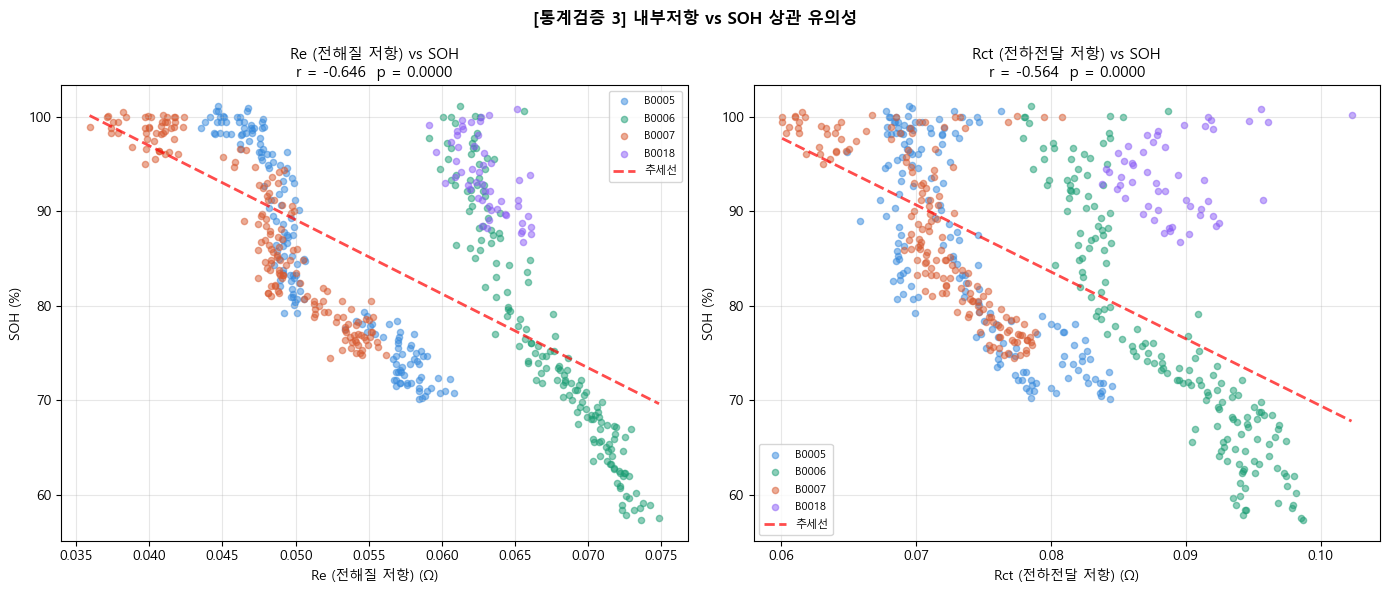

[저장] stat3_correlation_test.png


In [13]:
# ============================================================
# [5] Re·Rct vs SOH 상관 유의성 (Spearman) - 수정본
# ============================================================
print("\n" + "=" * 55)
print("[5] Re·Rct vs SOH 상관 유의성 (Spearman)")
print("=" * 55)

# impedance 순번 추가
df_imp_A = df_imp_A.sort_values(['battery_id','test_id'])
df_imp_A['imp_cycle_no'] = df_imp_A.groupby('battery_id').cumcount() + 1

# cycle_rank 생성
imp_A_ranked = df_imp_A.copy()
imp_A_ranked['cycle_rank'] = (
    imp_A_ranked.groupby('battery_id')['imp_cycle_no']
    .rank(method='first').astype(int)
)

dis_A_ranked = df_A_valid.copy()
dis_A_ranked['cycle_rank'] = (
    dis_A_ranked.groupby('battery_id')['discharge_cycle_no']
    .rank(method='first').astype(int)
)

# ★ 핵심 수정: Re·Rct만 선택해서 merge (컬럼 충돌 방지)
merged = dis_A_ranked.merge(
    imp_A_ranked[['battery_id','cycle_rank','Re','Rct']],
    on=['battery_id','cycle_rank'],
    how='inner',
    suffixes=('', '_imp')   # 충돌 시 impedance 쪽에 _imp 붙임
)

# Re_imp, Rct_imp 컬럼 정리
if 'Re_imp' in merged.columns:
    merged['Re']  = merged['Re_imp']
    merged['Rct'] = merged['Rct_imp']
    merged = merged.drop(columns=['Re_imp','Rct_imp'])

merged = merged.dropna(subset=['SOH','Re','Rct'])
print(f"매핑된 행 수: {len(merged)}\n")

# Spearman 상관 검정
for col, name in [('Re','Re (전해질 저항)'), ('Rct','Rct (전하전달 저항)')]:
    r, p = stats.spearmanr(merged[col], merged['SOH'])
    direction = "음의 상관 (저항↑ → SOH↓)" if r < 0 else "양의 상관"
    strength = (
        "매우 강함" if abs(r) >= 0.7 else
        "강함"     if abs(r) >= 0.5 else
        "중간"     if abs(r) >= 0.3 else "약함"
    )
    sig = "유의미" if p < 0.05 else "비유의"
    print(f"{name}")
    print(f"  Spearman r = {r:.4f}  |  p = {p:.6f}")
    print(f"  → {sig} / {direction} / 강도: {strength}\n")

# 배터리별 개별 상관계수
print("배터리별 Re-SOH / Rct-SOH Spearman 상관계수:")
for bid in sorted(merged['battery_id'].unique()):
    b = merged[merged['battery_id']==bid]
    if len(b) > 3:
        r_re,  p_re  = stats.spearmanr(b['Re'],  b['SOH'])
        r_rct, p_rct = stats.spearmanr(b['Rct'], b['SOH'])
        print(f"  {bid}: Re r={r_re:.3f}(p={p_re:.4f})  "
              f"Rct r={r_rct:.3f}(p={p_rct:.4f})")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
BATTERY_COLORS = {
    'B0005':'#378ADD','B0006':'#1D9E75',
    'B0007':'#D85A30','B0018':'#8B5CF6',
}

for ax, col, name in zip(
    axes,
    ['Re', 'Rct'],
    ['Re (전해질 저항)', 'Rct (전하전달 저항)']
):
    for bid in sorted(merged['battery_id'].unique()):
        b = merged[merged['battery_id']==bid]
        color = BATTERY_COLORS.get(bid, 'gray')
        ax.scatter(b[col], b['SOH'],
                   alpha=0.5, s=20, color=color, label=bid)

    # 추세선
    x = merged[col].values
    y = merged['SOH'].values
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            'r--', linewidth=2, alpha=0.7, label='추세선')

    r, p = stats.spearmanr(x, y)
    ax.set_xlabel(f'{name} (Ω)', fontsize=10)
    ax.set_ylabel('SOH (%)', fontsize=10)
    ax.set_title(f'{name} vs SOH\nr = {r:.3f}  p = {p:.4f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('[통계검증 3] 내부저항 vs SOH 상관 유의성',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stat3_correlation_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat3_correlation_test.png')


[6] 이상 배터리 검정 (Z-score & IQR)
목적: 그룹 내에서 통계적으로 이상한 배터리 식별

IQR 기준: 71.25 ~ 109.06
Z-score 기준: |Z| > 2

battery_id group  mean_SOH  z_score  iqr_outlier  z_outlier
     B0005     A 85.678929   -0.539        False      False
     B0006     A 76.830655   -1.822        False      False
     B0007     A 87.438333   -0.284        False      False
     B0018     A 84.676061   -0.684        False      False
     B0029     C 95.057500    0.821        False      False
     B0030     C 94.822000    0.787        False      False
     B0031     C 96.605250    1.045        False      False
     B0032     C 94.053500    0.675        False      False


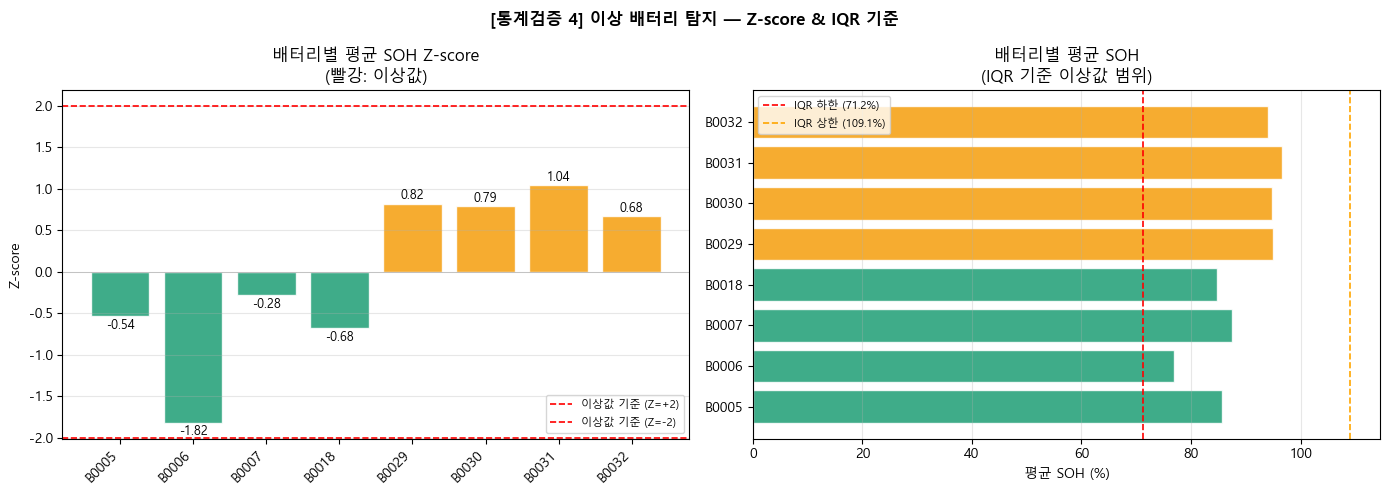

[저장] stat4_outlier_detection.png


In [14]:
print("\n" + "=" * 55)
print("[6] 이상 배터리 검정 (Z-score & IQR)")
print("=" * 55)
print("목적: 그룹 내에서 통계적으로 이상한 배터리 식별\n")
 
# 배터리별 평균 SOH 계산
battery_soh_mean = (
    pd.concat([df_A_valid, df_C_valid])
    .groupby(['battery_id','group'])['SOH']
    .mean()
    .reset_index()
    .rename(columns={'SOH':'mean_SOH'})
)
 
# Z-score
mean_all = battery_soh_mean['mean_SOH'].mean()
std_all  = battery_soh_mean['mean_SOH'].std()
battery_soh_mean['z_score'] = (
    (battery_soh_mean['mean_SOH'] - mean_all) / std_all
).round(3)
 
# IQR
Q1  = battery_soh_mean['mean_SOH'].quantile(0.25)
Q3  = battery_soh_mean['mean_SOH'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
 
battery_soh_mean['iqr_outlier'] = (
    (battery_soh_mean['mean_SOH'] < lower) |
    (battery_soh_mean['mean_SOH'] > upper)
)
battery_soh_mean['z_outlier'] = battery_soh_mean['z_score'].abs() > 2
 
print(f"IQR 기준: {lower:.2f} ~ {upper:.2f}")
print(f"Z-score 기준: |Z| > 2\n")
print(battery_soh_mean.to_string(index=False))
 
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
GROUP_COLORS = {'A':'#1D9E75','C':'#F59E0B'}
 
# Z-score 바차트
colors_z = [
    '#E24B4A' if row['z_outlier'] else GROUP_COLORS.get(row['group'],'gray')
    for _, row in battery_soh_mean.iterrows()
]
bars = axes[0].bar(battery_soh_mean['battery_id'],
                   battery_soh_mean['z_score'],
                   color=colors_z, alpha=0.85, edgecolor='white')
axes[0].axhline(y=2, color='red', linestyle='--', linewidth=1.2,
                label='이상값 기준 (Z=+2)')
axes[0].axhline(y=-2, color='red', linestyle='--', linewidth=1.2,
                label='이상값 기준 (Z=-2)')
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
for bar, val in zip(bars, battery_soh_mean['z_score']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15,
                 f'{val:.2f}', ha='center', fontsize=9)
axes[0].set_xticklabels(battery_soh_mean['battery_id'], rotation=45, ha='right')
axes[0].set_ylabel('Z-score')
axes[0].set_title('배터리별 평균 SOH Z-score\n(빨강: 이상값)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
 
# 평균 SOH + IQR 범위
axes[1].barh(battery_soh_mean['battery_id'],
             battery_soh_mean['mean_SOH'],
             color=colors_z, alpha=0.85, edgecolor='white')
axes[1].axvline(x=lower, color='red', linestyle='--', linewidth=1.2,
                label=f'IQR 하한 ({lower:.1f}%)')
axes[1].axvline(x=upper, color='orange', linestyle='--', linewidth=1.2,
                label=f'IQR 상한 ({upper:.1f}%)')
axes[1].set_xlabel('평균 SOH (%)')
axes[1].set_title('배터리별 평균 SOH\n(IQR 기준 이상값 범위)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='x', alpha=0.3)
 
fig.suptitle('[통계검증 4] 이상 배터리 탐지 — Z-score & IQR 기준',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stat4_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat4_outlier_detection.png')

In [ ]:
print("\n" + "=" * 55)
print("통계검증 전체 결과 요약")
print("=" * 55)
 
r_re,  p_re  = stats.spearmanr(merged['Re'],  merged['SOH'])
r_rct, p_rct = stats.spearmanr(merged['Rct'], merged['SOH'])
 
print(f"""
[핵심질문 1] 온도별 수명 차이
  그룹A 평균 EOL : {np.mean(grp_A_eol):.1f} 사이클
  그룹C 평균 EOL : {np.mean(grp_C_eol):.1f} 사이클
  p-value        : {test_p:.4f}
  결론           : {'유의미한 차이 있음 ' if test_p < 0.05 else '유의미한 차이 없음 '}
 
[핵심질문 2] 내부저항 vs SOH 상관
  Re-SOH   Spearman r : {r_re:.3f}  (p={p_re:.4f})  {' 유의미' if p_re < 0.05 else '비유의'}
  Rct-SOH  Spearman r : {r_rct:.3f}  (p={p_rct:.4f})  {' 유의미' if p_rct < 0.05 else '비유의'}
  결론 : {'내부저항이 SOH와 유의미한 음의 상관 → 조기 경보 가능성 있음 ' if p_re < 0.05 else '추가 확인 필요'}
 
[이상 배터리]
  Z-score 이상값 : {battery_soh_mean[battery_soh_mean['z_outlier']]['battery_id'].tolist()}
  IQR 이상값    : {battery_soh_mean[battery_soh_mean['iqr_outlier']]['battery_id'].tolist()}
""")
 
print("저장된 파일:")
print("  stat1_temperature_test.png  — 온도별 수명 검정")
print("  stat2_tukey_hsd.png         — Tukey HSD 사후검정")
print("  stat3_correlation_test.png  — 내부저항 상관 유의성")
print("  stat4_outlier_detection.png — 이상 배터리 탐지")



통계검증 전체 결과 요약

[핵심질문 1] 온도별 수명 차이
  그룹A 평균 EOL : 92.8 사이클
  그룹C 평균 EOL : nan 사이클
  p-value        : 0.3429
  결론           : 유의미한 차이 없음 ❌

[핵심질문 2] 내부저항 vs SOH 상관
  Re-SOH   Spearman r : -0.646  (p=0.0000)   유의미
  Rct-SOH  Spearman r : -0.564  (p=0.0000)   유의미
  결론 : 내부저항이 SOH와 유의미한 음의 상관 → 조기 경보 가능성 있음 

[이상 배터리]
  Z-score 이상값 : []
  IQR 이상값    : []

저장된 파일:
  stat1_temperature_test.png  — 온도별 수명 검정
  stat2_tukey_hsd.png         — Tukey HSD 사후검정
  stat3_correlation_test.png  — 내부저항 상관 유의성
  stat4_outlier_detection.png — 이상 배터리 탐지
